In [1]:
import Kea
from Kea.utils import plotting, data_reader
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

from Kea.api.sim_data import SimulationData, SimulationType

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

from scipy import fft

L = 2.*np.pi
D = 3
phys_dims = [L for _ in range(D)]

In [2]:
data = SimulationData(SimulationType.H5_SEAN, '/home/m/Documents/science_codes/Data/cmhd3d/', ['rho', 'vx', 'vy', 'vz'], '04', phys_dims=phys_dims)
_ = data.dephase_data(['rho'])

_ = data.project('rho', axis=2)
_ = data.dephase_data('x3proj_rho')

Reading file: z3-mhd3-04-uno-Xsp-rho.h5
Loaded rho
Reading file: z3-mhd3-04-uno-Xsp-v.h5
Loaded vx1
Reading file: z3-mhd3-04-uno-Xsp-v.h5
Loaded vx2
Reading file: z3-mhd3-04-uno-Xsp-v.h5
Loaded vx3
Created rho_dephase
Created x3proj_rho
Created x3proj_rho_dephase


-0.03874422802691291 -0.04880134864500851
0.048861113686771485 0.045601087748010194
5.366800753803247e-18 0.0


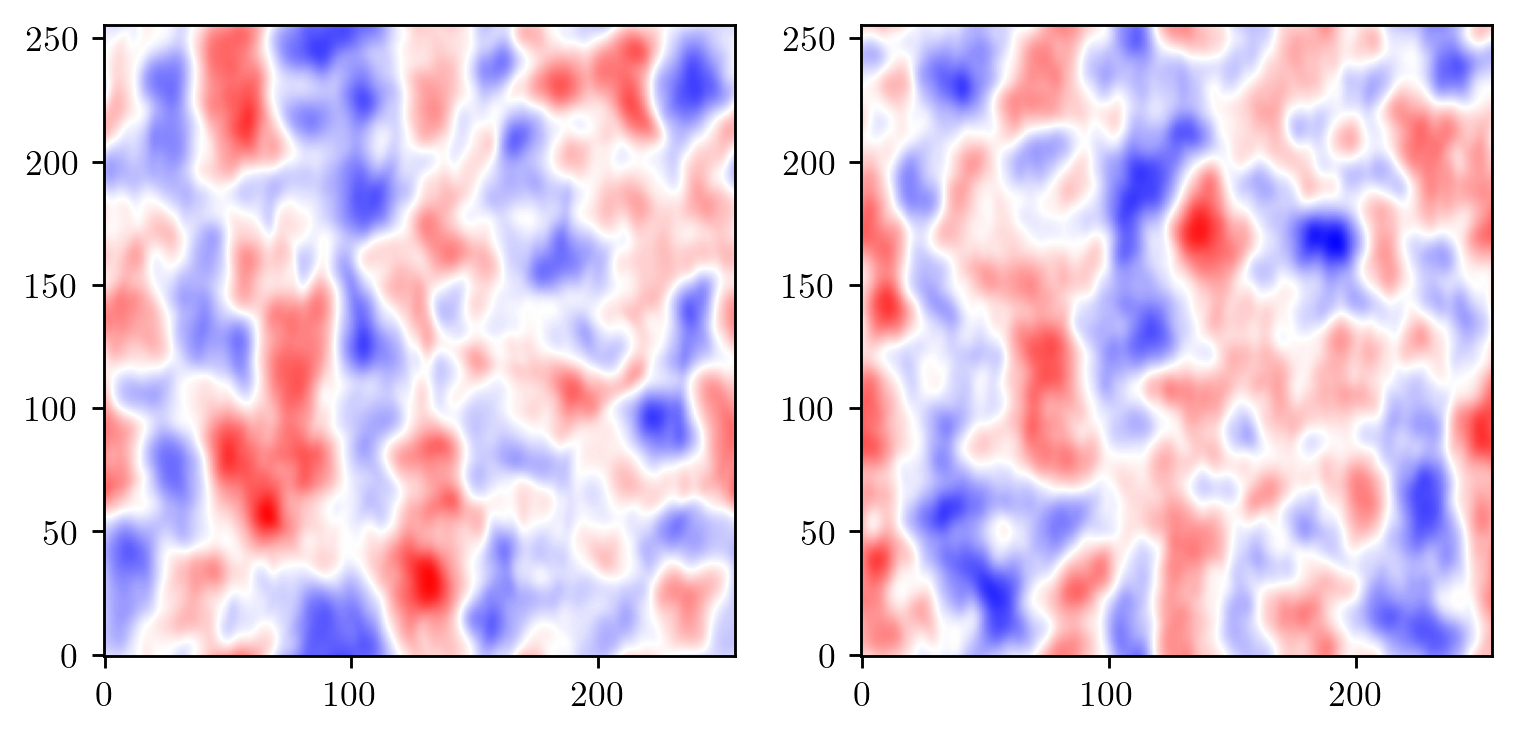

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(7., 3.5), dpi=256)

print(np.min(data.x3proj_rho-np.mean(data.x3proj_rho)), np.min(data.x3proj_rho_dephase-np.mean(data.x3proj_rho_dephase)))
print(np.max(data.x3proj_rho-np.mean(data.x3proj_rho)), np.max(data.x3proj_rho_dephase-np.mean(data.x3proj_rho_dephase)))
print(np.mean(data.x3proj_rho-np.mean(data.x3proj_rho)), np.mean(data.x3proj_rho_dephase-np.mean(data.x3proj_rho_dephase)))

ax[0].imshow(data.x3proj_rho-np.mean(data.x3proj_rho), cmap='bwr', origin='lower', vmin=-0.05, vmax=0.05)
ax[1].imshow(data.x3proj_rho_dephase-np.mean(data.x3proj_rho_dephase), cmap='bwr', origin='lower', vmin=-0.05, vmax=0.05)

In [4]:
rho_spec = data.spectrum('rho')
_, _ = rho_spec.integrate()
rhod_spec = data.spectrum('rho_dephase')
_, _ = rhod_spec.integrate()
proj_rho_spec = data.spectrum('x3proj_rho')
_, _ = proj_rho_spec.integrate()
proj_rhod_spec = data.spectrum('x3proj_rho_dephase')
_, _ = proj_rhod_spec.integrate()

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


Text(0.97, 0.97, '2D Projected')

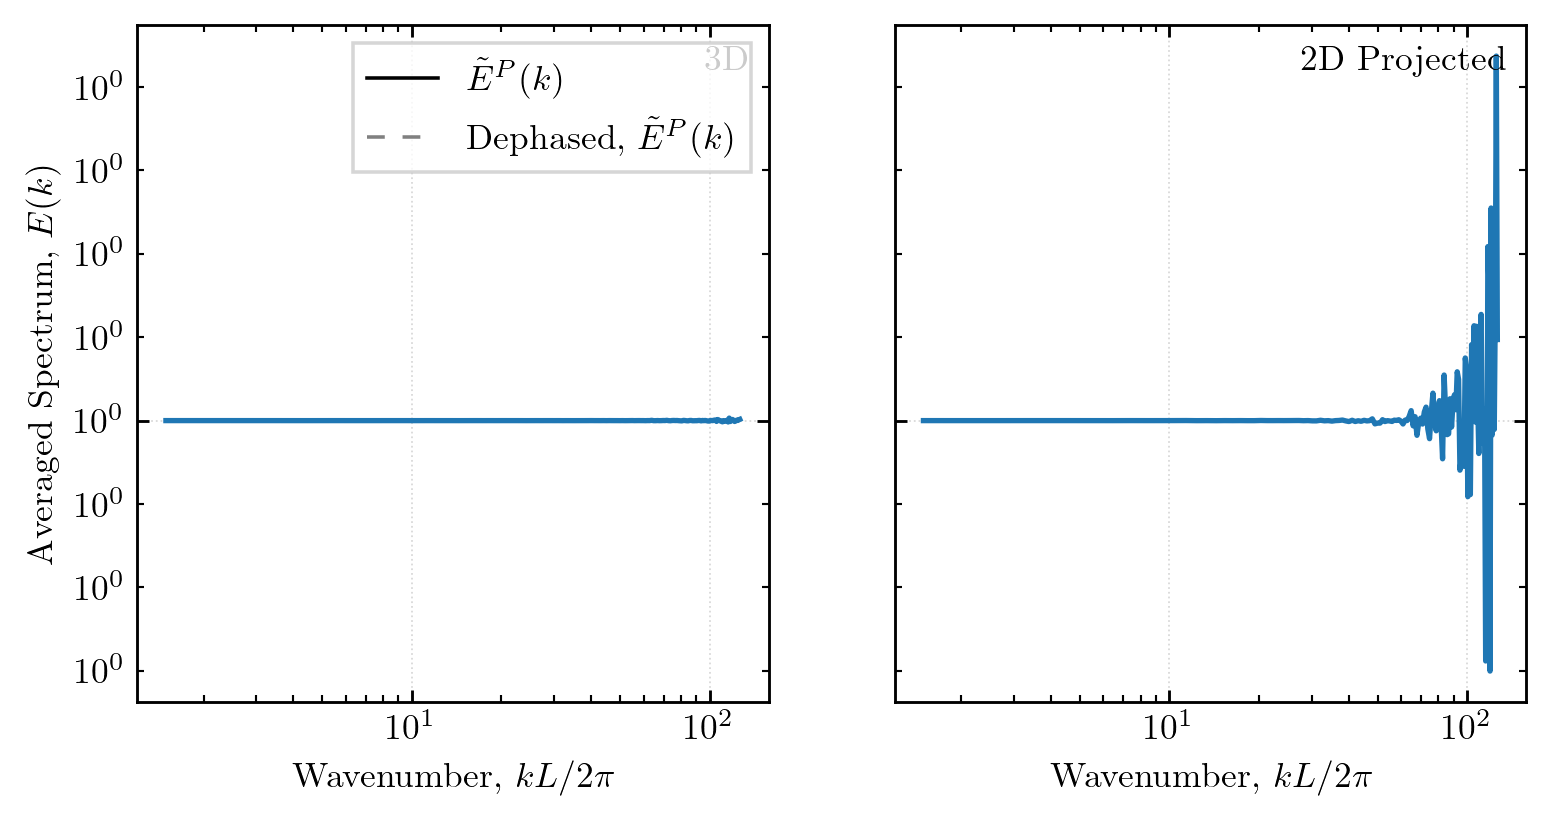

In [6]:
## Compare dephased
## 3D and Projected
fig, ax = plt.subplots(1, 2, figsize=(7., 3.5), dpi=256, sharey=True)

## 3D
#ax[0].loglog(rho_spec.modal_k, rho_spec.modal_fek, linewidth=1., color='black')
#ax[0].loglog(rhod_spec.modal_k, rhod_spec.modal_fek, linewidth=1., color='gray', linestyle=(0,(5,5)))

kk, bb = rhod_spec.bias(rho_spec)

ax[0].loglog(kk, bb)

## 2D
#ax[1].loglog(proj_rho_spec.modal_k, proj_rho_spec.modal_fek, linewidth=1., color='black')
#ax[1].loglog(proj_rhod_spec.modal_k, proj_rhod_spec.modal_fek, linewidth=1., color='gray', linestyle=(0,(5,5)))

kk, bb = proj_rhod_spec.bias(proj_rho_spec)
ax[1].loglog(kk, bb)

for axx in ax:
    axx.set_xscale('log')
    axx.set_yscale('log')

    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    axx.set_xlabel(r'Wavenumber, $kL/2\pi$')

ax[0].set_ylabel('Averaged Spectrum, $E(k)$')

ax[0].plot([], [], linewidth=1., color='black', label=r'$\tilde{E}^P(k)$')
ax[0].plot([], [], linewidth=1., color='gray', label=r'Dephased, $\tilde{E}^P(k)$', linestyle=(0,(5,5)))

ax[0].legend(frameon=True, fancybox=False)

ax[0].text(0.97, 0.97, r'3D', transform=ax[0].transAxes, ha='right', va='top')
ax[1].text(0.97, 0.97, r'2D Projected', transform=ax[1].transAxes, ha='right', va='top')
